# HeatGov AI - 00. FortyGuard API smoke test

Goal of this notebook: prove the plumbing works end to end before we build anything on top of it.

1. Load the project configuration and the API key from `.env`
2. Instantiate the official `FortyGuardClient`
3. Check how many API credits the key has
4. Run **one** heatmap request (`analytic_type="tcm"`, single day, 2025-07-15) over the Downtown Los Angeles polygon
5. Inspect the response: `activity_id`, statistics, tile count

The response is cached to `data/raw/`. Re-running this notebook will **not** call the API again.


## 1. Bootstrap

`backend/` is added to the import path so we can use both `config.py` and the vendored
`fortyguard` package from a notebook that lives in `notebooks/`.

In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BACKEND_DIR = PROJECT_ROOT / "backend"
sys.path.insert(0, str(BACKEND_DIR))

import config
from fortyguard import FortyGuardClient, FortyGuardError

print(config.describe())

Study area   : Downtown Los Angeles, CA
Bounding box : lon [-118.27, -118.23]  lat [34.03, 34.07]
Period       : 2025-07-01 -> 2025-07-31
Threshold    : 30.0 C (above)
Granularity  : 100 m
API key set  : True


## 2. Create the client

The client reads the key we passed in from `config`, which itself read it from `.env`.
No key is ever hard-coded in a notebook or a source file.

In [2]:
if not config.FORTYGUARD_API_KEY:
    raise RuntimeError(
        "FORTYGUARD_API_KEY is missing. Copy .env.example to .env and fill in your key."
    )

client = FortyGuardClient(
    api_key=config.FORTYGUARD_API_KEY,
    base_url=config.FORTYGUARD_BASE_URL,
)
print(f"Client ready against {client.base_url}")

Client ready against https://api.fortyguard.com


## 3. API credit usage

A cheap, non-async call. If this succeeds, the key is valid and the network path is open.

In [3]:
usage = client.fetch_api_key_usage()
print(json.dumps(usage, indent=2, default=str)[:2000])

{
  "api_key": null,
  "subscription_id": "sub_2j8oy6b7n4",
  "plan_details": {
    "plan_type": "Hackathon",
    "cycle_type": "Hackathon",
    "subscription_start_date": "Aug 19, 2026",
    "billing_period": "Aug 19, 2026 \u2013 Sep 23, 2026",
    "active": true,
    "credits_reset_date": "Sep 23, 2026"
  },
  "api_key_details": {
    "status": "active",
    "valid": true,
    "expiry_date": "2026-09-23T16:10:54.068571Z",
    "api_access_available": true
  },
  "credit_summary": {
    "total_available_credits": 2000000,
    "cycle_credits_used": 4220,
    "cycle_remaining_credits": 1995780,
    "cycle_usage_percentage": 0.2,
    "total_credits_used": 4220,
    "total_remaining_credits": 1995780
  },
  "activity_breakdown": [
    {
      "name": "Heatmap Generation",
      "credits": 4220,
      "count": 1,
      "percentage": 0.21
    },
    {
      "name": "Unused Credits",
      "credits": 1995780,
      "count": 0,
      "percentage": 99.79
    }
  ],
  "total_credits_used": 4220,

## 4. One test heatmap request

Parameters:

| Parameter | Value | Why |
|---|---|---|
| `analytic_type` | `tcm` | Snapshot temperature - the simplest analysis, good smoke test |
| `filter_type` | `3` | Single day |
| `start_date` | `2025-07-15` | Mid-July, representative of the study period |
| `granularity` | `100` m | Project-wide resolution |
| `polygon_aoi` | Downtown LA | From `config.DOWNTOWN_LA_POLYGON` |

This is an **async** endpoint: the client submits the job, receives an `activity_id`,
then polls the status endpoint until the task completes.

In [4]:
CACHE_FILE = config.RAW_DIR / f"test_tcm_{config.TEST_DATE}.json"

if CACHE_FILE.exists():
    print(f"Cache HIT  -> {CACHE_FILE.name} (no API call made)")
    response = json.loads(CACHE_FILE.read_text(encoding="utf-8"))
else:
    print("Cache MISS -> calling FortyGuard POST /v1/heatmap ...")
    response = client.create_heatmap(
        polygon_aoi=config.DOWNTOWN_LA_POLYGON,
        start_date=config.TEST_DATE,
        filter_type=config.FILTER_SINGLE_DAY,
        granularity=config.GRANULARITY_M,
        analytic_type="tcm",
        poll_interval=config.POLL_INTERVAL_S,
        timeout=config.REQUEST_TIMEOUT_S,
        verbose=True,
    )
    CACHE_FILE.write_text(json.dumps(response), encoding="utf-8")
    print(f"Cached     -> {CACHE_FILE}")

Cache HIT  -> test_tcm_2025-07-15.json (no API call made)


## 5. Inspect the response

In [5]:
activity_id = response["activity_id"]
result = response["result"]
stats = result.get("stats_data", {}) or {}
map_data = result.get("map_data") or {}
tiles = map_data.get("features", [])

print(f"activity_id    : {activity_id}")
print(f"result keys    : {list(result.keys())}")
print(f"tiles returned : {len(tiles):,}")

activity_id    : 2163aaf4-f9b7-49ad-a14d-b54661ce3892
result keys    : ['map_data', 'stats_data']
tiles returned : 1,607


In [6]:
print("--- stats_data ---")
for key, value in stats.items():
    preview = value
    if isinstance(value, list):
        preview = f"<list of {len(value)} values> e.g. {value[:5]}"
    elif isinstance(value, dict):
        preview = json.dumps(value, default=str)[:300]
    print(f"  {key}: {preview}")

--- stats_data ---
  temperature_stats: {"minimum": 21.7752, "maximum": 22.3821, "mean": 22.0548722464219, "standard_deviation": 0.16742551795093763}
  overall_temperature_distribution: <list of 5 values> e.g. [21.7752, 21.8641, 22.0801, 22.1834, 22.3821]
  normal_temperature_distribution: {"x_axis": [21.55259569256909, 21.562742693657025, 21.57288969474496, 21.583036695832895, 21.593183696920832, 21.603330698008765, 21.613477699096702, 21.62362470018464, 21.633771701272572, 21.64391870236051, 21.654065703448445, 21.66421270453638, 21.674359705624315, 21.684506706712252, 21.6946537078
  temperature_frequency: {"x_axis": [22.0], "y_axis": [1607]}


In [7]:
if tiles:
    print("--- first tile ---")
    print("properties:", json.dumps(tiles[0]["properties"], indent=2, default=str))
    print("geometry type:", tiles[0]["geometry"]["type"])
    print("first coordinate:", tiles[0]["geometry"]["coordinates"][0][0])
else:
    print("No tiles in map_data - inspect `result` above.")

--- first tile ---
properties: {
  "tile_id": 0,
  "average_temperature": 22.3533,
  "min_temperature": 17.3705,
  "max_temperature": 29.141
}
geometry type: Polygon
first coordinate: [-118.23134461587485, 34.0295481964399]


## 6. Sanity check: temperature distribution

A quick histogram confirms the tiles carry plausible values rather than nulls.

 average_temperature: min  21.78 | mean  22.05 | max  22.38 | spread  0.61
     min_temperature: min  16.97 | mean  17.29 | max  17.63 | spread  0.66
     max_temperature: min  28.72 | mean  29.28 | max  29.79 | spread  1.07

Unit check: 22.1 read as Celsius = 71.7 F -> plausible for LA in July.
Tile temperatures are reported in DEGREES CELSIUS.


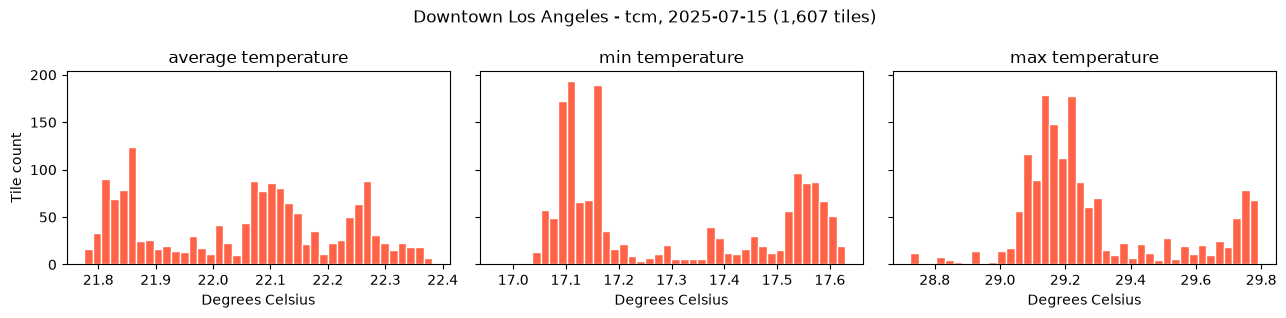

In [8]:
import matplotlib.pyplot as plt

# A tcm tile exposes three temperature fields (NOT a single "temperature" key).
TEMP_FIELDS = ("average_temperature", "min_temperature", "max_temperature")

series = {
    field: [f["properties"][field] for f in tiles if f["properties"].get(field) is not None]
    for field in TEMP_FIELDS
}

for field, values in series.items():
    lo, hi = min(values), max(values)
    mean = sum(values) / len(values)
    print(f"{field:>20}: min {lo:6.2f} | mean {mean:6.2f} | max {hi:6.2f} | spread {hi - lo:5.2f}")

# Unit check. A July daily mean near 22 can only be Celsius:
# 22 F would be -5.5 C, which is impossible in Los Angeles in July.
mean_avg = sum(series["average_temperature"]) / len(series["average_temperature"])
print("")
print(f"Unit check: {mean_avg:.1f} read as Celsius = {mean_avg * 9 / 5 + 32:.1f} F -> plausible for LA in July.")
print("Tile temperatures are reported in DEGREES CELSIUS.")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, field in zip(axes, TEMP_FIELDS):
    ax.hist(series[field], bins=40, color="tomato", edgecolor="white")
    ax.set_title(field.replace("_", " "))
    ax.set_xlabel("Degrees Celsius")
axes[0].set_ylabel("Tile count")
fig.suptitle(f"{config.CITY_NAME} - tcm, {config.TEST_DATE} ({len(tiles):,} tiles)")
fig.tight_layout()
plt.show()

---

**Step 1 is complete when:** the credit usage prints, `activity_id` is a real id,
`tiles returned` is greater than zero, and `data/raw/test_tcm_2025-07-15.json` exists on disk.